# Installation and configuration of IBL packages

# IBL Behavior Project

## Contents

- [Initial code: load IBL data](#installation-and-configuration-of-ibl-packages)
- [Q1. Logistic regression](#q1-logistic-regression)
  - [Q1-1. Data preprocessing overview](#q1-1-data-preprocessing-overview)
  - [Q1-2. Keep fully-trained sessions](#q1-2-keep-only-fully-trained-sessions)
  - [Q1-3. Create binary choice column](#q1-3-create-binary-choice-column)
  - [Q1-4. Select input and target columns](#q1-4-select-input-and-target-columns)
  - [Q1-5. Split trials for each mouse](#q1-5-split-trials-for-each-mouse)
  - [Q1-6. Fit logistic regression for each mouse](#q1-6-fit-logistic-regression-for-each-mouse)
  - [Q1-7. Predict choice probabilities](#q1-7-predict-choice-probabilities-on-the-test-set)
  - [Q1-8. Calculate empirical probability](#q1-8-calculate-empirical-probability-on-the-test-set)
  - [Q1-9. Calculate log likelihood](#q1-9-calculate-log-likelihood-on-the-test-set)
  - [Q1-10. Results table](#q1-10-results-table)
  - [Q1-11. Interpret log likelihood](#q1-11-interpret-log-likelihood)
  - [Q1-12. Visual check for one mouse](#q1-12-visual-check-for-one-mouse)
  - [Q1-13. Psychometric curves across mice](#q1-13-psychometric-curves-across-mice)
  - [Q1-14. Q1 interpretation](#q1-14-q1-interpretation)
- [Q2. Logistic regression + lapse](#q2-logistic-regression--lapse)
- [Q3. Choice history](#q3-choice-history)
- [Q3 interaction: previous choice x previous reward](#q3-7-add-previous_choice-x-previous_reward-interaction)
- [Q4. Stationarity](#q4-is-mouse-behavior-stationary)
  - [Q4-1. Create a copy of Q3 model data](#q4-1-create-a-copy-of-q3-model-data)
  - [Q4-2. Sliding-window analysis](#q4-2-we-need-one-session-for-sliding-window-analysis)


In [1]:
!pip install --quiet ONE-api
!pip install --quiet ibllib

In [2]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

/usr/local/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [3]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

# Finding subjects with training data

In [4]:
import numpy as np

# Find all aggregate training datasets from IBL behaviour paper
datasets = one.alyx.rest('datasets', 'list', tag='2021_Q1_IBL_et_al_Behaviour', name='_ibl_subjectTrials.table.pqt')

# Find the subject name from the info stored in the relative path
subjects = np.unique([d['file_records'][0]['relative_path'].split('/')[2] for d in datasets])

# Loading trials data for a single subject

In [5]:
# Load in the subjectTrials table and sessionTrials table for the first subject
subject = subjects[0]
subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')
session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

# Add in lab, task_protocol, subject name information from the sessions table
if 'task_protocol' in subject_trials:
    subject_trials = subject_trials.drop('task_protocol', axis=1)
subject_trials = subject_trials.set_index('session').join(session_trials.drop('date', axis=1))

/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


The `subject_trials` table contains all the trials data for each training session collected in the subject. See [here](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.ls81qq9ihg4x) for more information about this dataset.

We can find the number of sessions collected, or the number of times the subject was run under a specific task protocol

In [6]:
# Find the number of sessions for this subject
n_sessions = subject_trials.index.unique().size
print(f'Subject {subject} has {n_sessions} sessions')

# Find the number of times a task protocol was run
n_protocols = subject_trials[~subject_trials.index.duplicated()].task_protocol.value_counts()
print(n_protocols)

Subject CSHL045 has 76 sessions
task_protocol
_iblrig_tasks_biasedChoiceWorld6.3.1      17
_iblrig_tasks_trainingChoiceWorld6.1.3    14
_iblrig_tasks_trainingChoiceWorld6.2.5    12
_iblrig_tasks_trainingChoiceWorld6.3.1    11
_iblrig_tasks_biasedChoiceWorld6.2.5       6
_iblrig_tasks_trainingChoiceWorld6.0.6     3
_iblrig_tasks_trainingChoiceWorld6.2.4     3
_iblrig_tasks_ephysChoiceWorld6.2.5        3
_iblrig_tasks_trainingChoiceWorld6.2.1     2
_iblrig_tasks_ephysChoiceWorld6.4.0        2
_iblrig_tasks_trainingChoiceWorld6.1.1     1
_iblrig_tasks_trainingChoiceWorld6.1.2     1
_iblrig_tasks_trainingChoiceWorld6.2.0     1
Name: count, dtype: int64


We can get the trials data for an individual session of choice, here a the first session using the biasedChoiceWorld protocol

In [7]:
# Get the trials data for a single session
# Find a session run under biasedChoiceWorld
sess = subject_trials[subject_trials['task_protocol'].str.contains('biasedChoiceWorld')].index.unique()[0]
trials = subject_trials[subject_trials.index == sess]

Using this data we can plot the psychometric curve and compute some performance metrics, for example the number of trials in the session or the performance of the mouse on easy trials (50% and 100% contrast)

Number of trials for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 682
Performance easy for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 0.9457364341085271


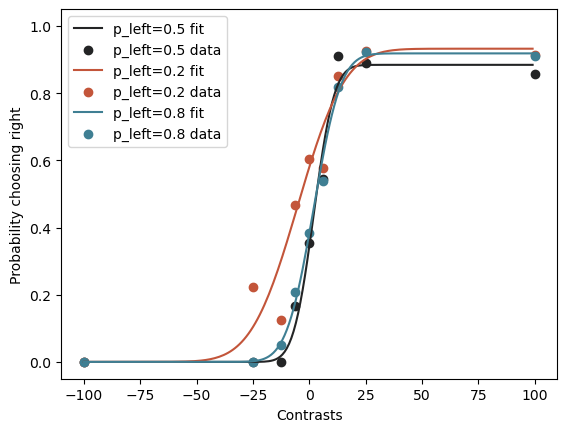

In [8]:
from brainbox.behavior.training import plot_psychometric, compute_n_trials, compute_performance_easy, compute_performance

plot_psychometric(trials)
n_trials = compute_n_trials(trials)
perf_easy = compute_performance_easy(trials)
print(f'Number of trials for session {sess}: {n_trials}')
print(f'Performance easy for session {sess}: {perf_easy}')

## Combining training criteria

Another [dataset](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.18vu2zskyq0r) is available that contains information about the session at which the subject reached certain training criteria in the IBL training pipeline. More information can be found about the training pipeline in the study [A standardized and reproducible method to measure decision-making in mice](https://doi.org/10.1101/2020.01.17.909838).

We can download this dataset in the following way

In [9]:
subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

We can combine this with our subject trials table to see how the subject progressed

In [10]:
subject_trials = (subject_trials
          .join(subject_training.set_index('session'))
          .sort_values(by=['session_start_time', 'intervals_0']))
subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

Our subject trials table now has a new column that indicates the training criteria of the mouse at each session. We can use this information to make a plot of how the performance of the mouse improved across training days.

We will need to compute the performance per session and add this column to our dataframe and also add in a column for training day.

In [11]:
sessions = subject_trials.index.unique()
for n_sess, sess in enumerate(sessions):
  trials = subject_trials[subject_trials.index == sess]
  perf_easy = compute_performance_easy(trials)
  subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
  subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess

Note since we already ordered by session_start_time above our table was already sorted. Here we have simply assigned each training session to a training day but there are some cases where multiple training sessions were run on the same day so this may be something you want to account for in your analysis.

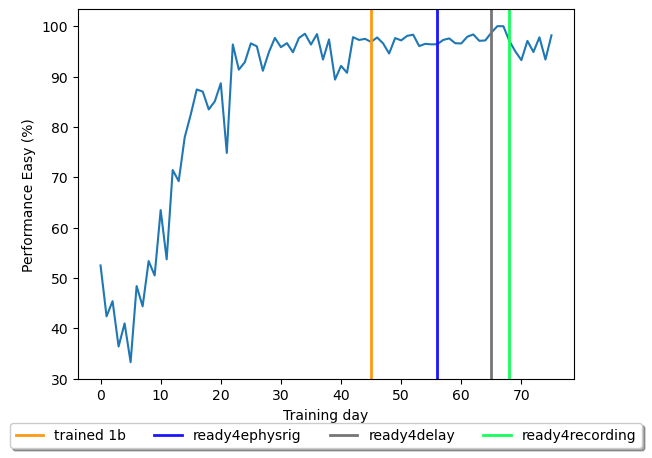

In [12]:
import matplotlib.pyplot as plt
from ibllib.pipes.training_status import TRAINING_STATUS
fig, ax = plt.subplots(1, 1)
ax.plot(subject_trials['training_day'], subject_trials['performance_easy'] * 100)
ax.set_xlabel("Training day")
ax.set_ylabel("Performance Easy (%)")
status = subject_trials.drop_duplicates(subset='training_status', keep='first')
for _, st in status.iterrows():
    if st['training_status'] in ['untrainable', 'unbiasable']:
        continue
    if TRAINING_STATUS[st['training_status']][0] <= 0:
        continue
    ax.axvline(st['training_day'], linewidth=2,
               color=np.array(TRAINING_STATUS[st['training_status']][1]) / 255, label=st['training_status'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
                   fancybox=True, shadow=True, ncol=5)

# Combining data across multiple subjects

We can loop over all the subjects available to get a large dataframe that contains the data for all the subjects. Here is an example of how this can be done


In [13]:
import pandas as pd

all_trials = []

# Download two tables, subject trials table and subject training table and combine
for i, subject in enumerate(subjects):
  if np.mod(i, 50) == 0:
    print(f'{i}/{len(subjects)}')

  # Load trials table for subject
  subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')

  # Load sessions table for subject
  session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

  # Load training status for subject
  subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

  # Combine the two tables
  subject_trials = (subject_trials
            .set_index('session')
            .join(subject_training.set_index('session'))
            .sort_values(by=['session_start_time', 'intervals_0']))
  subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

  # Join sessions table for number, task_protocol, etc.
  if 'task_protocol' in subject_trials:
      subject_trials = subject_trials.drop('task_protocol', axis=1)
  subject_trials = subject_trials.join(session_trials.drop('date', axis=1))

  # Sort the trials by session start time and trial number
  subject_trials = subject_trials.sort_values(by=['session_start_time', 'intervals_0'])


  # add in extra columns for performance easy and training day
  sessions = subject_trials.index.unique()
  for n_sess, sess in enumerate(sessions):
    trials = subject_trials[subject_trials.index == sess]
    perf_easy = compute_performance_easy(trials)
    subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
    subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess


  all_trials.append(subject_trials)

all_trials = pd.concat(all_trials)

0/140


/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL047/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL049/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default

50/140


/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/angelakilab/IBL-T3/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/mrsicflogellab/IBL_001/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/mrsicflogellab/IBL_002/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


100/140


Once we have this large training table aggregated across all subjects we can manipulate this table to view different properties. For example we can see how the pyshcometric curves varies across the different training stages across all subjects

<Axes: xlabel='signed_contrast', ylabel='choice'>

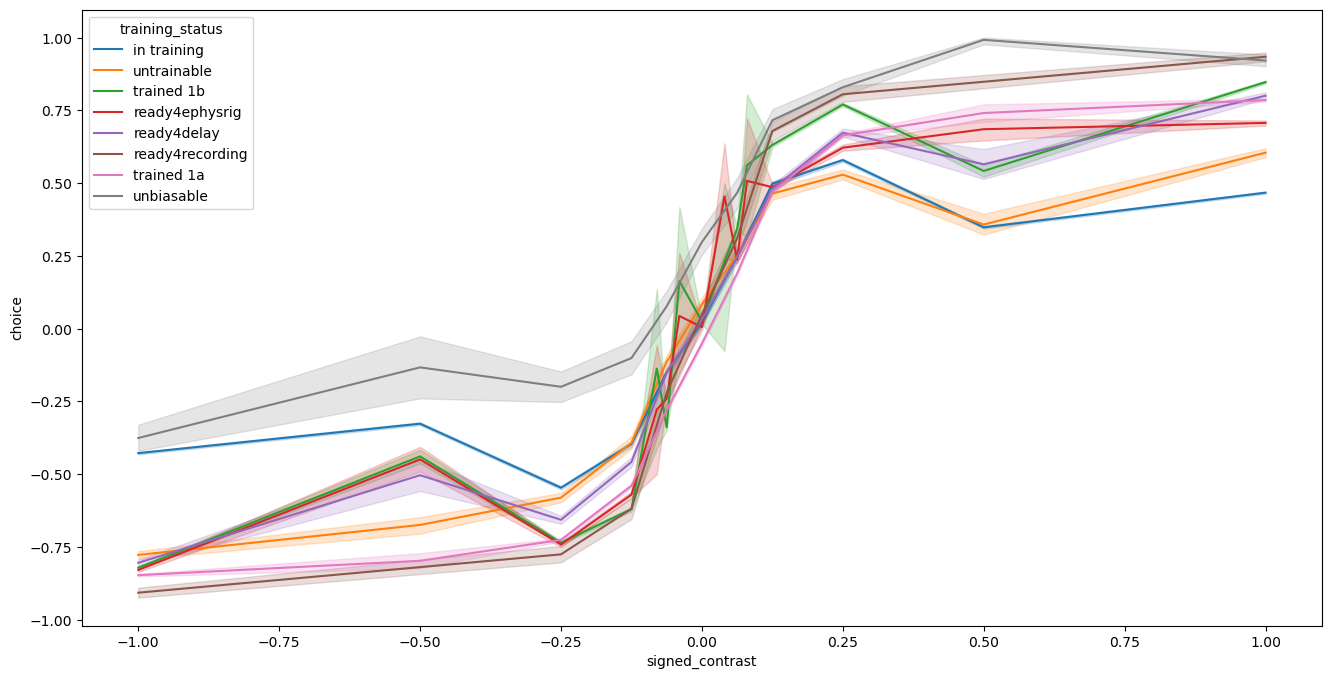

In [14]:
import seaborn as sns
# plot psychometric curves for the whole dataframe
all_trials = all_trials.reset_index()
all_trials['signed_contrast'] = np.nan
i = np.isnan(all_trials['contrastRight'])
all_trials.loc[i , 'signed_contrast'] = all_trials.loc[i, 'contrastLeft']
all_trials.loc[~i, 'signed_contrast'] = - all_trials.loc[~i, 'contrastRight']

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 8))
sns.lineplot(data=all_trials.loc[all_trials['probabilityLeft'] == 0.5], x='signed_contrast', y='choice', hue='training_status', ax=ax)

Or we can look how the performance on easy trial progresses over training days across labs

/usr/local/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


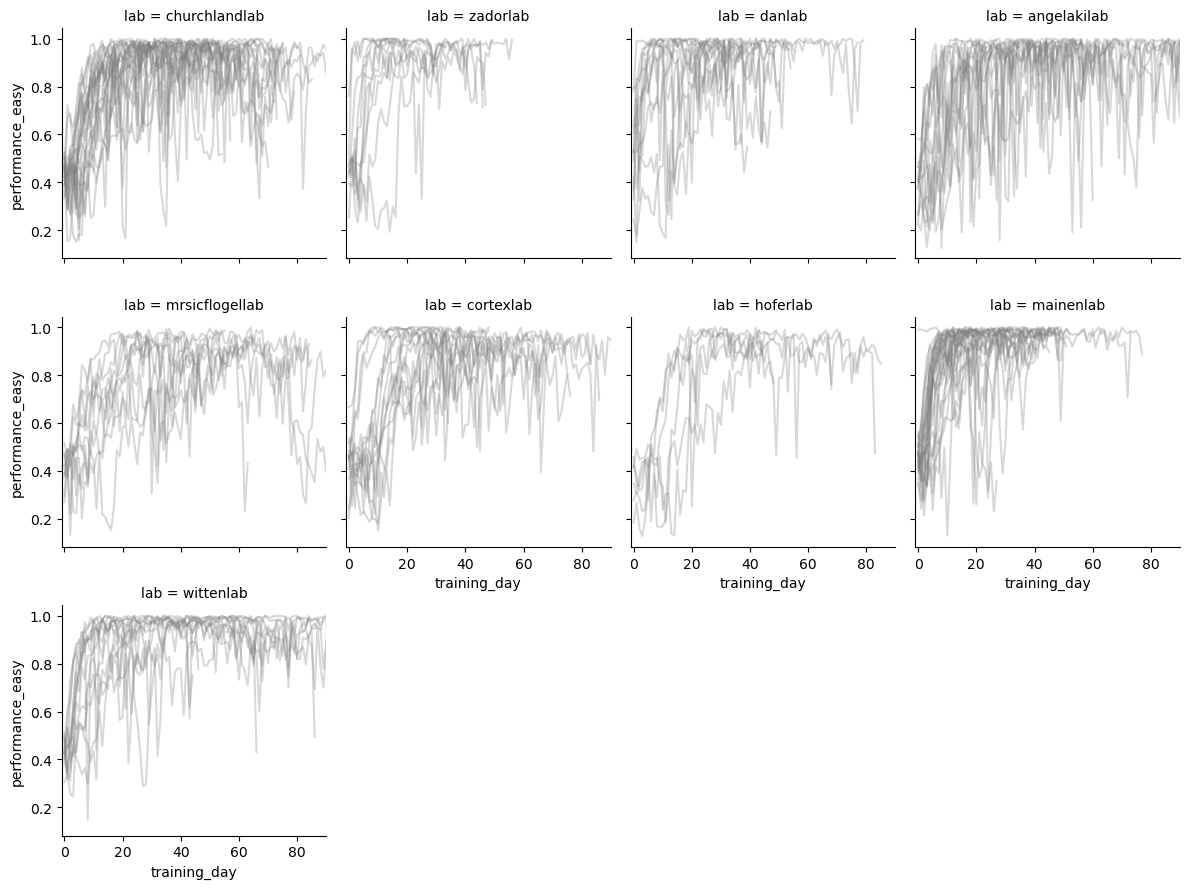

In [15]:
# Remove duplicate rows that we don't need for the plots
fig = sns.FacetGrid(all_trials.drop_duplicates('session'),
                    col="lab", col_wrap=4,
                    sharex=True, sharey=True, aspect=1, hue="subject", xlim=[-1, 90])
fig.map(sns.lineplot, "training_day",
        "performance_easy", color='gray', alpha=0.3)

# Additional resources

Documentation

- [ONE documentation](https://int-brain-lab.github.io/iblenv/notebooks_external/one_quickstart.html#)
- [Getting started with ONE](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7)
- [Loading trials data](https://int-brain-lab.github.io/iblenv/notebooks_external/loading_trials_data.html)


Where can I find help?
- Issues with the data? Post an issue here: https://neurostars.org/ with the tag `ibl`
- Alternatively post an issue here: https://github.com/int-brain-lab/iblenv/issues
- General questions about the datasets or publications? Email: info@internationalbrainlab.org




> *All data are made available under the CC BY 4.0 license.*

### Q1. Logistic regression

### Q1-1. Data preprocessing overview
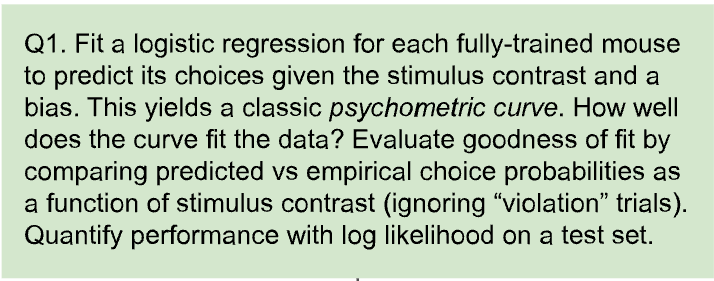


`all_trials` already contains trial data from all mice and all sessions.

For Q1, we need these columns:

- `subject` - mouse ID
- `session` - session ID
- `training_status` - training status
- `contrastLeft` - left stimulus contrast
- `contrastRight` - right stimulus contrast
- `choice` - mouse choice (`-1`, `1`, or violation)
- `signed_contrast` - stimulus contrast already created from `contrastLeft` and `contrastRight`

most of column already exists in `all_trials`, the next preprocessing steps are:

1. Keep only fully-trained sessions.
2. Remove violation trials.
3. Convert `choice` into `choice_binary` for logistic regression.


In [16]:

print(all_trials.columns)

Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast'],
      dtype='object')


### Q1-1. Data preprocessing steps

We create a copy of `all_trials` and call it `df_q1`.


In [17]:
df_all = all_trials.copy()

### Q1-2. Keep only fully-trained sessions

For this, we use the column `training_status`.

Fully-trained statuses are:

- `ready4ephysrig`
- `ready4delay`
- `ready4recording`

filter:
- mouse/session is fully trained
- choice is valid: `-1` or `1`
- `signed_contrast` is not missing


In [18]:
FULLY_TRAINED_STATUSES = [
    'ready4ephysrig',
    'ready4delay',
    'ready4recording'
]

is_fully_trained = df_all['training_status'].isin(FULLY_TRAINED_STATUSES)
is_valid_choice = df_all['choice'].isin([-1, 1])    
has_signed_contrast = df_all['signed_contrast'].notna()

df_q1 = df_all.loc[
    is_fully_trained & is_valid_choice & has_signed_contrast
].copy()



### Q1-3. Create binary choice column

Logistic regression usually need the output variable to be binary: `0` or `1`.

The original `choice` column has values `-1` and `1`.

So we create `choice_binary` column:

- `choice = 1` becomes `choice_binary = 1`
- `choice = -1` becomes `choice_binary = 0`

This column will be the target variable for logistic regression.


In [19]:
# Create binary choice for logistic regression
# choice = 1  -> choice_binary = 1
# choice = -1 -> choice_binary = 0

df_q1['choice_binary'] = 0
df_q1.loc[df_q1['choice'] == 1, 'choice_binary'] = 1 #For rows where choice is 1, set choice_binary to 1.


df_q1[['choice', 'choice_binary']].head()

,choice,choice_binary
41824,1.0,1
41825,1.0,1
41826,1.0,1
41827,1.0,1
41828,-1.0,0


### Q1-4. Select input and target columns

For logistic regression, we need:

- `X` - input feature
- `y` - target we want to predict

In this task:

- `X = signed_contrast`
- `y = choice_binary`

The model will learn how stimulus contrast predicts the mouse choice.


In [20]:
X = df_q1[['signed_contrast']]
y = df_q1['choice_binary']

print(X.head())
print("----------------------")
print(y.head())

       signed_contrast
41824          -0.1250
41825           0.0625
41826          -0.1250
41827          -0.0000
41828          -0.0000
----------------------
41824    1
41825    1
41826    1
41827    1
41828    0
Name: choice_binary, dtype: int64


### Q1-5. Split trials for each mouse

We do not split mice into 80% and 20%.

Instead, for each mouse separately, we split that mouse's trials:

- 80% of trials are used for training
- 20% of trials are used for testing

This is needed because each mouse gets its own logistic regression model.
The test trials are used later to calculate log likelihood.


The model learns two parameters:

- `bias` — intercept
- `contrast_weight` — effect of stimulus contrast

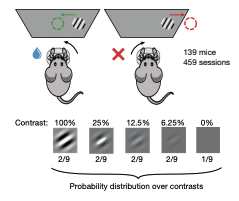


### Q1-6. Fit logistic regression for each mouse

After splitting the trials, we train the model using only the training data.

The model uses:

- `signed_contrast` as input
- `choice_binary` as target

The model learns two parameters:

- `bias` — intercept
- `contrast_weight` — effect of stimulus contrast


вероятность того, что модель предсказывает выбор, закодированный как 1.

P(choice_binary = 1) = sigmoid(bias + contrast_weight * signed_contrast)

Для каждой мыши отдельно обучили Logistic Regression, чтобы предсказывать choice_binary по signed_contrast.

In [21]:
print(df_q1.columns)

display(df_q1[['subject', 'session','choice','contrastLeft','contrastRight']].head(5))


Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast', 'choice_binary'],
      dtype='object')


,subject,session,choice,contrastLeft,contrastRight
41824,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.125
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,0.0625,NaN
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.125
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.000
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-1.0,NaN,0.000


Здесь df_q1 делится на группы по мышам.
Каждая группа = все trials одной мыши.

In [22]:
for subject, mouse_data in df_q1.groupby('subject'):
    print("Subject:", subject)
    print(mouse_data.shape)
    display(mouse_data.head(2))
    break

Subject: CSHL045
(17953, 36)


,session,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,...,lab,subject,number,task_protocol,projects,performance_easy,training_day,session_number,signed_contrast,choice_binary
41824,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0000,10.361503,7.1431,7.7614,1.0,NaN,NaN,0.125,7.7923,...,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.964072,56.0,NaN,-0.1250,1
41825,85501aad-64e6-4137-a44e-2c933c9eec5f,10.8138,15.470302,11.3389,13.8841,1.0,11.3105,0.0625,NaN,13.8842,...,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.964072,56.0,NaN,0.0625,1


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

mouse_models = {}


for subject, mouse_data in df_q1.groupby('subject'):
    X = mouse_data[['signed_contrast']]
    y = mouse_data['choice_binary']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0, #you get the same split every time. это не количество.Это просто номер фиксированного варианта случайности.
        stratify=y
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)

    mouse_models[subject] = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'bias': model.intercept_[0],
        'contrast_weight': model.coef_[0][0],

    }


### Q1-7. Predict choice probabilities on the test set

По сути мы берем уже обученную модель и прогоняем через нее test data, то есть данные, на которых модель не обучалась.


After training the logistic regression model on the training trials, we apply the trained model to the test trials.

The test trials were not used during fitting, so they act as unseen data.

We use `predict_proba - это готовая функция внутри sklearn модели LogisticRegression`, because the task asks for choice probabilities, not only final class labels.

For each test trial, the model predicts:

`P(choice_binary = 1)`

This is the model's predicted probability that the mouse makes the choice coded as `1`.

These predicted probabilities are later compared with the empirical choice probabilities from the same test set.


In [24]:
for subject, result in mouse_models.items():
    model = result['model']
    X_test = result['X_test']

    class_1_index = list(model.classes_).index(1) #найди, в какой колонке predict_proba находится вероятность класса 1.

    p_test_predicted = model.predict_proba(X_test)
    p_test_predicted = p_test_predicted[:, class_1_index] #[:, 1] значит: взять все строки и вторую колонку.

    mouse_models[subject]['p_test_predicted'] = p_test_predicted

### Q1-8. Calculate empirical probability on the test set


$$
\hat{P}_{\text{test}}(\text{choice}=1 \mid \text{signed contrast}=c)
=

\frac{\text{Number of test trials where choice}=1\text{ at contrast }c}
{\text{Total number of test trials at contrast }c}
$$


Here, 

X is `signed_contrast` 

Y is `choice_binary`




In [25]:
for subject, result in mouse_models.items():
    test_data = result['X_test'].copy()
    test_data['choice_binary'] = result['y_test']

    p_test_empirical = (test_data
                                .assign(choice_is_1 = test_data['choice_binary'] == 1)
                                .groupby('signed_contrast')['choice_is_1']
                                .mean()
                          )

    mouse_models[subject]['p_test_empirical'] = p_test_empirical

### Q1-9. Calculate log likelihood on the test set

We use the test trials to measure how well the model predicts unseen data.

`log_loss` gives negative log likelihood.

So we multiply it by `-1` to get log likelihood.

A better model has log likelihood closer to `0`.

A model near chance is around `log(0.5) = -0.693`.


In [26]:
from sklearn.metrics import log_loss

for subject, result in mouse_models.items():

    y_test = result['y_test']
    
    p_test_predicted = result['p_test_predicted']

    log_likelihood = -log_loss(y_test, p_test_predicted)

    mouse_models[subject]['log_likelihood'] = log_likelihood

### Q1-10. Results table

After fitting the model for each mouse, we save the important results in one table.

For each mouse, we save:

- `subject` - mouse ID
- `bias` - model intercept  - here logictic regression calculate automitically 
- `contrast_weight` - effect of stimulus contrast
- `log_likelihood` - log loss fuction

This table helps compare model performance across mice.


In [27]:
#lets summarize the results

results = []

for subject, result in mouse_models.items():
    model = result['model']

    results.append({
        'subject': subject,
        'bias': model.intercept_[0],
        'contrast_weight': model.coef_[0][0],
        'log_likelihood': result['log_likelihood']
    })

results_df = pd.DataFrame(results)

results_df.head()

,subject,bias,contrast_weight,log_likelihood
0,CSHL045,-0.029792,7.671385,-0.449487
1,CSHL046,-0.060998,5.092882,-0.511274
2,CSHL047,-1.124388,5.097826,-0.427543
3,CSHL049,0.461201,7.375145,-0.459950
4,CSHL051,-0.584094,3.514391,-0.535279


### Q1-11. Interpret log likelihood

|  `log_likelihood` | Интерпретация |
|---:|---|
| `0` to `-0.3` | Very good / очень хорошая модель |
| `-0.3` to `-0.5` | Good / хорошая модель |
| `-0.5` to `-0.65` | Okay / moderate / средняя модель |
| Around `-0.693` | Chance level / уровень случайного угадывания |
| Less than `-0.693` | Bad / хуже случайного угадывания |


### Q1-12. Visual check for one mouse

We already evaluated the model numerically using the log-likelihood in Step 10. 
Here, we evaluate the model visually:

- Empirical probability represents the mouse’s actual choices in the test data.

- Predicted probability represents the probabilities estimated by the logistic regression model.

If the predicted curve is close to the empirical data points, the psychometric curve fits the test data well.


In [28]:
#This selects one mouse from the results_df table by taking the row at index 6.(just example of mouse #6) 
subject = results_df['subject'].iloc[23] #Это выбирает одну мышь из таблицы results_df берет элемент с индексом 6.

#Gets the empirical probabilities for the selected mouse.
p_test_empirical = mouse_models[subject]['p_test_empirical'] #реальные probabilities на test set по contrast.
contrast_values = p_test_empirical.index.to_frame(index=False) # just convert to DataFrame.

#Gets the trained logistic regression model for the selected mouse.
mouse6model = mouse_models[subject]['model']
class_1_index = list(mouse6model.classes_).index(1) 

p_test_predicted_curve = mouse6model.predict_proba(contrast_values)
p_test_predicted_curve = p_test_predicted_curve[:, class_1_index]

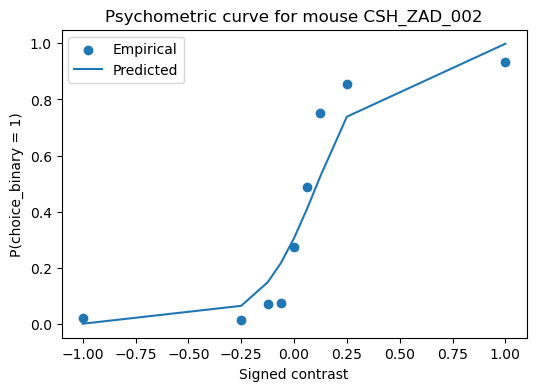

In [29]:
plt.figure(figsize=(6, 4))

plt.scatter(
    p_test_empirical.index,
    p_test_empirical.values,
    label='Empirical'
)

plt.plot(
    p_test_empirical.index,
    p_test_predicted_curve,
    label='Predicted'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title(f'Psychometric curve for mouse {subject}')
plt.legend()
plt.show()

This code finds the log-likelihood for the selected mouse and prints the mouse ID and its log-likelihood value.

In [30]:
mouse_ll = results_df.loc[
    results_df['subject'] == subject,
    'log_likelihood'
].values[0]

print("Subject:", subject)
print("Log likelihood:", mouse_ll)

Subject: CSH_ZAD_002
Log likelihood: -0.4296368624958548


This code combines the empirical and predicted psychometric curves for all mice and then calculates the average curve.

In [31]:
all_curves = []       #creates an empty list to store results for every mouse.

for subject, result in mouse_models.items():
    model = result['model']

    # empirical probabilities already calculated on test set
    p_test_empirical = result['p_test_empirical']       #gets the real probability of choosing 1 for each contrast.

    # use the same signed_contrast values for predicted curve
    contrast_values = p_test_empirical.index.to_frame(index=False)   #prepares the contrast values for the model.
    class_1_index = list(model.classes_).index(1)         #keeps only the probability of choice = 1.

    p_test_predicted_curve = model.predict_proba(contrast_values)        #calculates the predicted probabilities.
    p_test_predicted_curve = p_test_predicted_curve[:, class_1_index]

    curve_df = pd.DataFrame({                           #creates one table for the current mouse.
        'subject': subject,
        'signed_contrast': p_test_empirical.index,
        'p_test_empirical': p_test_empirical.values,
        'p_test_predicted': p_test_predicted_curve
    })

    all_curves.append(curve_df)              #adds this mouse’s results to the list.

all_curves_df = pd.concat(all_curves, ignore_index=True)         #combines all mice into one DataFrame.

mean_curve = (
    all_curves_df
    .groupby('signed_contrast')                 #groups results by contrast.
    .agg(
        mean_empirical=('p_test_empirical', 'mean'),        #calculates the average empirical probability across mice.
        mean_predicted=('p_test_predicted', 'mean')          #calculates the average predicted probability across mice.
    )
    .reset_index()
    .sort_values('signed_contrast')
)


### Q1-13. Psychometric curves across mice

- This plot compares the observed and model-predicted probabilities.

- The empirical probability is calculated from the actual choices in the test data. 
If the red and black lines are close, the model fits the average behavior of the mice well.


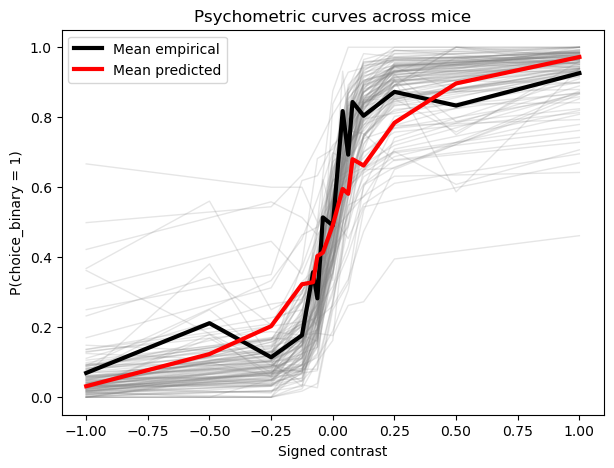

In [32]:
plt.figure(figsize=(7, 5))

for subject, mouse_curve in all_curves_df.groupby('subject'):
    mouse_curve = mouse_curve.sort_values('signed_contrast')

    plt.plot(
        mouse_curve['signed_contrast'],
        mouse_curve['p_test_empirical'],
        color='gray',
        alpha=0.2,
        linewidth=1
    )

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_empirical'],
    color='black',
    linewidth=3,
    label='Mean empirical'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_predicted'],
    color='red',
    linewidth=3,
    label='Mean predicted'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Psychometric curves across mice')
plt.legend()
plt.show()

### Q1 interpretation


- The main result is that the probability of choice_binary = 1 increased as signed_contrast increased. 

- This shows that stimulus contrast strongly affects the mouse’s choice.

- The red predicted curve follows the black empirical curve quite well, so logistic regression captures the main relationship between contrast and choice.

- The average predicted curve was close to the average empirical curve, so the model captured the main relationship between contrast and choice.

- logistic regression provided a good basic psychometric model, but adding behavioral history variables could improve the fit.

## Q2. Logistic regression + lapse

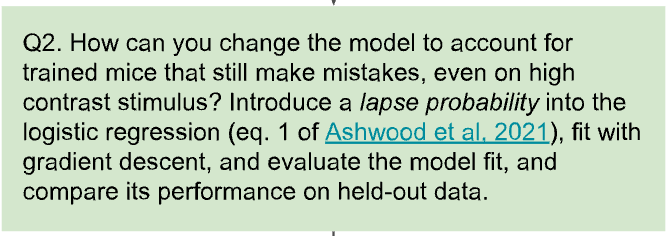

### Q2-1. From Q1 to Lapse Analysis

In Q1, logistic regression captured the main relationship between `signed_contrast` and mouse choice. As contrast increased, the probability of `choice_binary = 1` also increased.
In Q1, we used standard logistic regression to model how signed_contrast affects the mouse’s choice.

The model captured the main trend well with Logistic Regression:

$$
P(Y=1 \mid x)
=

\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

The sigmoid function is:

$$
\operatorname{sigmoid}(z)
=

\frac{1}{1+e^{-z}}
$$



### Q2-2. However, some mice still made errors at high contrast. 
##### Standard logistic regression usually predicts probabilities close to 0 or 1 at high contrast, so it may not capture these lapse errors.
Ashwood et al. suggest that lapses may not be completely random. 
Mice can switch between engaged and disengaged behavioral states, and disengaged states can continue across several trials. 

High-contrast errors:

`abs(signed_contrast) >= 0.5` and `feedbackType == -1`


### Q2-3. The mouse sometimes chooses based on the stimulus, and sometimes makes a random choice because of a lapse.

So, we build a new, extended model:

- Logistic regression describes the mouse’s choice based on signed_contrast(Q1).

- λ describes how often the mouse ignores the stimulus and chooses randomly.

- sklearn.LogisticRegression cannot estimate λ, so for the lapse model we usually write our own probability function and optimize the negative log-likelihood.


Это формула логистической регрессией с учетом + lapse_probability


$$ P =
\frac{\lambda}{2}
+
(1 - \lambda)
\cdot
\frac{1}{1 + e^{-(b + wx)}}
$$


### Q2-4. How we get prev formula?


We use 0.5 because during a lapse, 

we assume that the mouse chooses randomly between two possible choices: 0 and 1. 

Then, each choice has a probability of 50%.


The general model is:

$$
P
=

\gamma
+
(1-\gamma-\delta)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

If the lower and upper lapse rates are equal:

$$
\gamma=\delta=\frac{\lambda}{2}
$$

Substitute them into the general formula:

$$
P
=

\frac{\lambda}{2}
+
\left(1-\frac{\lambda}{2}-\frac{\lambda}{2}\right)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

then we get:

$$
P
=

\frac{\lambda}{2}
+
(1-\lambda)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

Here, 
*  γ - gamma - its errors at high negative contrast.
*  δ - delta - its errors at high positive contrast.
*  λ - lambda, the total lapse probability.



### Q2-5. Gradient descent is used to find the parameters.

   - In Q1, sklearn LogisticRegression() already did optimization for us. 

   - It learned ->  `bias + contrast_weight + internally.`
 
 - In Q2, because we add a custom lapse_probability, normal LogisticRegression() cannot fit it directly. 

 - So we write our own gradient descent to learn ->  `bias + contrast_weight + lapse_probability`

#### Gradient descent update

$$
b \leftarrow b - \alpha \frac{\partial  LogLoss}{\partial b}
$$

$$
w \leftarrow w - \alpha \frac{\partial  LogLoss}{\partial w}
$$

$$
lapse_{\text{raw}} \leftarrow lapse_{\text{raw}} - \alpha \frac{\partial  LogLoss}{\partial lapse_{\text{raw}}}
$$

where:

- $\alpha$ = learning rate

- $\lambda$ = lapse probability

- $p$ = predicted probability that `choice_binary = 1`

### Q2-6. log likelihood / log loss

The negative log likelihood is:

$$
LOG LOSS =
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i \log(p_i)
+
(1 - y_i)\log(1 - p_i)
\right]
$$

                                        
`Log Loss = - mean( y * log(p) + (1 - y) * log(1 - p) )`

where:

- `y_i` = real choice on trial \(i\), either `0` or `1`
- `p_i` = predicted probability of `choice_binary = 1`
- `N` = number of trials

A smaller `Log loss` means better model fit.

посчитать вероятность choice = 1 с учётом двух вещей:

- влияния signed_contrast через logistic regression

- случайных ошибок мыши через lapse_probability.

То есть модель описывает -> обычно мышь выбирает по stimulus, но иногда игнорирует его и выбирает случайно.

### Q2-7. Coding Part 

* Selects trials with high contrast: `|signed_contrast| >= 0.5`.

  * high contrast

  * `feedbackType == -1`
  
Using `.abs()` includes both strong left and strong right contrasts.


In [33]:
#Step 2. get high-contrast mistakes 
high_contrast_trials = df_q1[df_q1['signed_contrast'].abs() >= 0.5]
print(df_q1['signed_contrast'].min())
print(df_q1['signed_contrast'].max())
print(sorted(df_q1['signed_contrast'].dropna().unique()))


high_contrast_mistakes = df_q1[
    (df_q1['signed_contrast'].abs() >= 0.5) &
    (df_q1['feedbackType'] == -1)
]

-1.0
1.0
[-1.0, -0.5, -0.25, -0.125, -0.08, -0.0625, -0.04, -0.0, 0.04, 0.0625, 0.08, 0.125, 0.25, 0.5, 1.0]


### Q2-7.1 Implementation of a Logistic + Lapse Ftiing Model Using Gradient Descent


In [34]:
# Step 3.
# Logistic + Lapse model with random search start + fast gradient descent

LEARNING_RATE = 0.01
N_ITERATIONS = 500
N_RANDOM_STARTS = 100


# step 3
#find sigmoid
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))


#logictic regression + lapse probability
def predict_proba_lapse_model(x, bias, contrast_weight, lapse_probability):
    # x for our task is signed_contrast
    p_logistic = sigmoid(bias + contrast_weight * x)

    p = (
        lapse_probability / 2
        + (1 - lapse_probability) * p_logistic
    )

    return p

# step 6. calculate negative log likelihood - лог лосс binary cross-entropy
def negative_log_likelihood(y, p):
    eps = 1e-9     # потому что log(0) нельзя посчитать. Это бесконечность/ошибка.
    p = np.clip(p, eps, 1 - eps) #np.clip нужен просто для safety. Он защищает формулу от ошибки. np.clip(1.5, 0, 1) -> 1 np.clip(-0.2, 0, 1) -> 0

    loss = -np.mean( y * np.log(p)  + (1 - y) * np.log(1 - p))

    return loss


def lapse_model_loss(params, x, y):
    bias = params[0]
    contrast_weight = params[1]
    lapse_probability = params[2]

    p = predict_proba_lapse_model(
        x,
        bias,
        contrast_weight,
        lapse_probability
    )

    loss = negative_log_likelihood(y, p)

    return loss


def random_search_lapse_start(x, y, n_random=N_RANDOM_STARTS):
    best_params = None
    best_loss = np.inf

    for i in range(n_random):
        params = np.array([
            np.random.uniform(-3, 3),       # random bias
            np.random.uniform(0, 12),       # random contrast_weight
            np.random.uniform(0.001, 0.2)   # random lapse_probability
        ])

        loss = lapse_model_loss(params, x, y)

        if loss < best_loss:
            best_loss = loss
            best_params = params

    return best_params, best_loss


def calculate_gradients_fast(params, x, y):
    bias = params[0]
    contrast_weight = params[1]
    lapse_probability = params[2]

    s = sigmoid(bias + contrast_weight * x)

    p = (
        lapse_probability / 2
        + (1 - lapse_probability) * s
    )

    eps = 1e-9
    p = np.clip(p, eps, 1 - eps)

    dloss_dp = (p - y) / (p * (1 - p))

    dp_dbias = (1 - lapse_probability) * s * (1 - s)
    dp_dweight = (1 - lapse_probability) * s * (1 - s) * x
    dp_dlapse = 0.5 - s

    grad_bias = np.mean(dloss_dp * dp_dbias)
    grad_weight = np.mean(dloss_dp * dp_dweight)
    grad_lapse = np.mean(dloss_dp * dp_dlapse)

    return np.array([
        grad_bias,
        grad_weight,
        grad_lapse
    ])

In [35]:
def fit_lapse_model(
    x_train,
    y_train_array,
    learning_rate=LEARNING_RATE,
    n_iterations=N_ITERATIONS
):
    params, start_loss = random_search_lapse_start(
        x_train,
        y_train_array
    )

    loss_history = []

    for i in range(n_iterations):
        loss = lapse_model_loss(params, x_train, y_train_array)
        loss_history.append(loss)

        gradients = calculate_gradients_fast(
            params,
            x_train,
            y_train_array
        )

        params = params - learning_rate * gradients

        params[2] = np.clip(params[2], 0.001, 0.4)

        if i > 50 and abs(loss_history[-2] - loss_history[-1]) < 1e-7:
            break

    return {
        'bias': params[0],
        'contrast_weight': params[1],
        'lapse_probability': params[2],
        'start_loss': start_loss,
        'final_loss': loss_history[-1],
        'loss_history': loss_history,
        'n_iterations_used': i + 1
    }

#### Just Note

`eps = 1e-9` is a very small number that we choose ourselves.

We use `eps = 1e-9` to avoid `log(0)`, because `log(0)` goes to negative infinity.

If `p` becomes exactly `0` or `1`, the log loss can become infinite, and gradient descent may break.

To avoid this, we use:

`p = np.clip(p, eps, 1 - eps)`

This keeps `p` slightly above `0` and slightly below `1`, so the loss can be calculated safely.

### Q2-7.2 Training and Testing the Logistic + Lapse Model

* Trains a separate lapse model for each mouse.
* Splits each mouse’s trials into 80% training and 20% testing data.
* Learns:
  * bias,
  * effect of contrast,
  * lapse probability.
* Predicts choices on unseen test trials.
* Saves the model parameters, data, and predictions for each mouse.


In [36]:
mouse_logictic_lapse_models = {}

for subject, mouse_data in df_q1.groupby('subject'):
    # 1. Use data from one mouse
    X = mouse_data[['signed_contrast']]
    y = mouse_data['choice_binary']

    # 2. Split this mouse's trials into 80% train and 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=y
    )

    # 3. Convert only TRAIN data to numpy arrays for gradient descent, sklearn handles pandas automatically. 
    x_train = X_train['signed_contrast'].to_numpy()  
    y_train_array = y_train.to_numpy()

    # 4. Fit lapse model only on TRAIN data  


    params = fit_lapse_model(
        x_train,
        y_train_array,
        learning_rate=LEARNING_RATE,
        n_iterations=N_ITERATIONS
    )

    # 5. Convert only TEST data to numpy arrays for held-out evaluation
    x_test = X_test['signed_contrast'].to_numpy()
    y_test_array = y_test.to_numpy()

    # 6. Predict on TEST data
    p_test_lapse = predict_proba_lapse_model(
        x_test,
        params['bias'],
        params['contrast_weight'],
        params['lapse_probability']
    )

    # 7. Save everything
    mouse_logictic_lapse_models[subject] = {
        'params': params,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'x_train': x_train,
        'y_train_array': y_train_array,
        'x_test': x_test,
        'y_test_array': y_test_array,
        'p_test_lapse': p_test_lapse
    }

### Q2-7.3 Find a Log-Likelihood of Logistic + Lapse Models 

In [37]:
# calculate log likelihood on held-out test data
for subject, result in mouse_logictic_lapse_models.items():
    y_test_array = result['y_test_array']
    p_test_lapse = result['p_test_lapse']

    log_likelihood_lapse = -negative_log_likelihood(
        y_test_array,
        p_test_lapse
    )

    mouse_logictic_lapse_models[subject]['log_likelihood_lapse'] = log_likelihood_lapse

### Q2-7.4 Result Table Log-Likelihood: Logistic + Lapse Models

In [38]:
# make results table
lapse_results = []

for subject, result in mouse_logictic_lapse_models.items():
    params = result['params']

    lapse_results.append({
        'subject': subject,
        'bias_lapse': params['bias'],
        'contrast_weight_lapse': params['contrast_weight'],
        'lapse_probability': params['lapse_probability'],
        'log_likelihood_lapse': result['log_likelihood_lapse']
    })

lapse_results_df = pd.DataFrame(lapse_results)

display(lapse_results_df.head())

,subject,bias_lapse,contrast_weight_lapse,lapse_probability,log_likelihood_lapse
0,CSHL045,0.020060,11.844779,0.053158,-0.419600
1,CSHL046,-0.028188,9.712897,0.089082,-0.480504
2,CSHL047,-1.732496,11.434997,0.097079,-0.406914
3,CSHL049,0.567787,10.228582,0.044239,-0.422396
4,CSHL051,-0.679613,11.865971,0.175012,-0.518403


### Q2-7.5 Compare Log-Likelihood: Logistic + Lapse Models vs. Q1 Logistic Models

In [39]:
# compare Q1 logistic regression vs Q2 lapse model
comparison_df = results_df.merge(
    lapse_results_df,
    on='subject'
)

comparison_df['log_likelihood_improvement'] = (
    comparison_df['log_likelihood_lapse']
    - comparison_df['log_likelihood']
)

comparison_df['is_lapse_better'] = (
    comparison_df['log_likelihood_improvement'] > 0
)

display(comparison_df.head())

,subject,bias,contrast_weight,log_likelihood,bias_lapse,contrast_weight_lapse,lapse_probability,log_likelihood_lapse,log_likelihood_improvement,is_lapse_better
0,CSHL045,-0.029792,7.671385,-0.449487,0.020060,11.844779,0.053158,-0.419600,0.029887,True
1,CSHL046,-0.060998,5.092882,-0.511274,-0.028188,9.712897,0.089082,-0.480504,0.030770,True
2,CSHL047,-1.124388,5.097826,-0.427543,-1.732496,11.434997,0.097079,-0.406914,0.020629,True
3,CSHL049,0.461201,7.375145,-0.459950,0.567787,10.228582,0.044239,-0.422396,0.037554,True
4,CSHL051,-0.584094,3.514391,-0.535279,-0.679613,11.865971,0.175012,-0.518403,0.016876,True


### Q2-7.6 Checks the average model performance across mice: Q1 vs Q2

- Mean Q1 log likelihood — average test log-likelihood of the Q1 logistic model.

- Mean Q2 lapse log likelihood — average test log-likelihood of the logistic + lapse model.

- Mean improvement — average difference between the two models.

In [40]:
# check average improvement
print("Mean Q1 log likelihood:", comparison_df['log_likelihood'].mean())
print("Mean Q2 lapse log likelihood:", comparison_df['log_likelihood_lapse'].mean())
print("Mean improvement:", comparison_df['log_likelihood_improvement'].mean())

Mean Q1 log likelihood: -0.4816715549986881
Mean Q2 lapse log likelihood: -0.45205158459042694
Mean improvement: 0.029619970408261233


### Q2-8 Visualization: Logistic Regression Q1  vs Logistic Regression with Lapse Q2 vs Empirical Probability

This plot compares the observed mouse choices with predictions from two models:

* Black: average empirical behavior
* Blue: Q1 logistic model
* Red: Q2 logistic + lapse model
* Gray: individual mice

Both models follow the empirical psychometric curve closely, with only small differences between them.


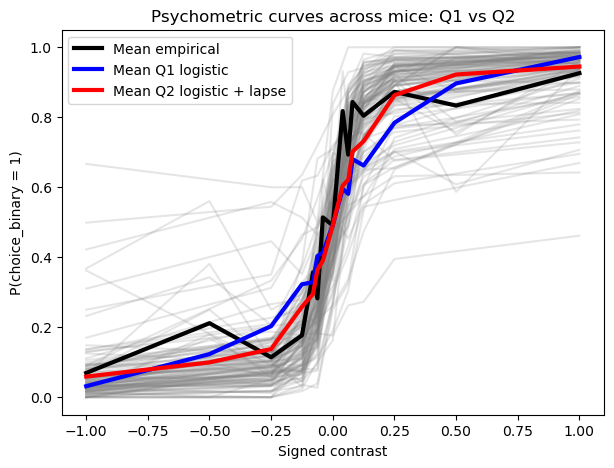

In [41]:
# Add Q2 Logistic + Lapse predictions
all_curves_df['p_test_lapse'] = [
    predict_proba_lapse_model(
        np.array([contrast]),
        mouse_logictic_lapse_models[subject]['params']['bias'],
        mouse_logictic_lapse_models[subject]['params']['contrast_weight'],
        mouse_logictic_lapse_models[subject]['params']['lapse_probability']
    )[0]
    for subject, contrast in zip(
        all_curves_df['subject'],
        all_curves_df['signed_contrast']
    )
]

mean_curve = (
    all_curves_df
    .groupby('signed_contrast', as_index=False)
    .agg(
        mean_empirical=('p_test_empirical', 'mean'),
        mean_q1=('p_test_predicted', 'mean'),
        mean_q2=('p_test_lapse', 'mean')
    )
)

plt.figure(figsize=(7, 5))

for subject, mouse_curve in all_curves_df.groupby('subject'):
    mouse_curve = mouse_curve.sort_values('signed_contrast')

    plt.plot(
        mouse_curve['signed_contrast'],
        mouse_curve['p_test_empirical'],
        color='gray',
        alpha=0.2
    )

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_empirical'],
    color='black',
    linewidth=3,
    label='Mean empirical'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_q1'],
    color='blue',
    linewidth=3,
    label='Mean Q1 logistic'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_q2'],
    color='red',
    linewidth=3,
    label='Mean Q2 logistic + lapse'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Psychometric curves across mice: Q1 vs Q2')
plt.legend()
plt.show()

Next plot is for **one selected mouse**, identified by `subject` in Q1.

It compares:

* empirical test data for that mouse,
* the Q1 standard logistic model,
* the Q2 logistic + lapse model.

The curves show how both models predict that mouse’s choices across signed contrast levels.


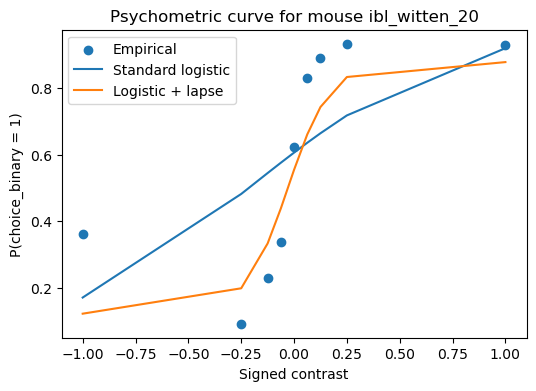

In [42]:
# Logistic + lapse model predictions
lapse_params = mouse_logictic_lapse_models[subject]['params']

p_test_lapse_curve = predict_proba_lapse_model(
    p_test_empirical.index.to_numpy(),
    lapse_params['bias'],
    lapse_params['contrast_weight'],
    lapse_params['lapse_probability']
)

# Plot
plt.figure(figsize=(6, 4))

plt.scatter(
    p_test_empirical.index,
    p_test_empirical.values,
    label='Empirical'
)

plt.plot(
    p_test_empirical.index,
    p_test_predicted_curve,
    label='Standard logistic'
)

plt.plot(
    p_test_empirical.index,
    p_test_lapse_curve,
    label='Logistic + lapse'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title(f'Psychometric curve for mouse {subject}')
plt.legend()
plt.show()

## Q3. Choice history

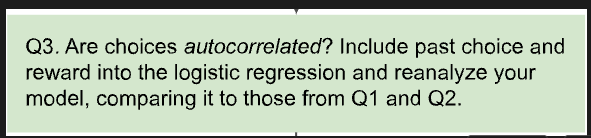

# Q3. Are choices autocorrelated?

### Are the mouse’s choices influenced by past trials?

In Q1, the model used only current stimulus contrast: `choice ~ signed_contrast`

In Q2, the model added lapse probability: `choice ~ signed_contrast + lapse`

In Q3, we need to add behavioral history: `choice ~ signed_contrast + previous_choice + previous_reward`

- `previous_choice` -> what the mouse chose on the previous trial

- `previous_reward` -> whether the mouse was rewarded/correct on the previous trial

Then compare Q3 with Q1 and Q2 using log-likelihood.

If Q3 has better log-likelihood, it means past choice/reward helps predict current choice. 

That would suggest choices are autocorrelated.

### Q3-1. Preparing Previous-Trial Columns for Q3 

- For Q3, I make a new copy called `df_q3` and add past-trial columns only to this copy.

- sort the trials in time order. `sorting` is important because `shift(1)` takes the row directly above as the prev trial.

- group by subject and session so previous trials are calculated separately within each mouse and session.

-  `prev_choice_binary` from the previous trial’s choice.

- `prev_rewarded` from the previous trial’s feedback.

-  remove the first trial of each session because it has no previous trial. 



In [43]:
# Create Q3 copy. Do not change df_q1.
df_q3 = df_q1.copy(deep=True)

#We sort trials are sorted by subject, session_start_time, session, and intervals_0 so the previous-trial columns are calculated in the correct time order.
sort_columns_q3 = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q3.columns
]
df_q3 = df_q3.sort_values(sort_columns_q3).copy(deep=True)


# create previous choice column for each mouse and session.
df_q3['prev_choice_binary'] = (
    df_q3
    .groupby(['subject', 'session'])['choice_binary']
    .shift(1)            #shift(1) moves the choices down by one row, so each trial gets the choice from the trial before it

)

# Create previous feedback column for each mouse and session. feedbackType = 0/1 here both
df_q3['prev_feedbackType'] = (
    df_q3
    .groupby(['subject', 'session'])['feedbackType']
    .shift(1)
)

# Convert previous reward to binary:
                            # previous rewarded trial = 1
                            # previous unrewarded/error trial = 0
df_q3['prev_rewarded'] = (df_q3['prev_feedbackType'] == 1).astype(float)

# Remove trials with no previous trial information.
df_q3_model = df_q3.loc[
      df_q3['prev_choice_binary'].notna() &
      df_q3['prev_feedbackType'].notna()
].copy(deep=True)

# Convert previous choice/reward to integer 0/1.
df_q3_model['prev_choice_binary'] = df_q3_model['prev_choice_binary'].astype(int)
df_q3_model['prev_rewarded'] = df_q3_model['prev_rewarded'].astype(int)

display(
    df_q3_model[[
        'subject',
        'session',
        'signed_contrast',
        'choice_binary',
        'prev_choice_binary',
        'prev_rewarded'
    ]].head()
)

print('Q1 rows:', len(df_q1))
print('Q3 rows after removing first trial of each session:', len(df_q3_model))


,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1


Q1 rows: 2132658
Q3 rows after removing first trial of each session: 2129698


In [44]:
# Add behavior type: win-stay / win-shift / lose-stay / lose-shift

df_q3_model['behavior_type'] = 'unknown'

# rewarded previous trial + same choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 1) &
    (df_q3_model['choice_binary'] == df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'win-stay'

# rewarded previous trial + switched choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 1) &
    (df_q3_model['choice_binary'] != df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'win-shift'

# unrewarded previous trial + same choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 0) &
    (df_q3_model['choice_binary'] == df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'lose-stay'

# unrewarded previous trial + switched choice now
df_q3_model.loc[
    (df_q3_model['prev_rewarded'] == 0) &
    (df_q3_model['choice_binary'] != df_q3_model['prev_choice_binary']),
    'behavior_type'
] = 'lose-shift'

display(
    df_q3_model[
        [
            'subject',
            'session',
            'signed_contrast',
            'choice_binary',
            'prev_choice_binary',
            'prev_rewarded',
            'behavior_type'
        ]
    ].head(20)
)


print('Q1 rows:', len(df_q1))
print('Q3 rows after removing first trial of each session:', len(df_q3_model))

,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded,behavior_type
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0,lose-stay
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1,win-stay
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0,lose-stay
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0,lose-shift
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1,win-stay
41830,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,0,0,1,win-stay
41831,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.1250,1,0,1,win-shift
41832,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.1250,1,1,1,win-stay
41833,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0000,0,1,1,win-shift
41834,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-1.0000,0,0,0,lose-stay


Q1 rows: 2132658
Q3 rows after removing first trial of each session: 2129698


### Q3-2. Fit logistic regression with past choice and reward

For each mouse separately, we train a new logistic regression model.

Input variables:

- `signed_contrast`

- `prev_choice_binary`

- `prev_rewarded`

Target variable:

- `choice_binary`

Important interpretation:

- If `prev_choice_weight` is positive, then the mouse tends to repeat the previous choice.

- If `prev_choice_weight` is negative, then the mouse tends to switch away from the previous choice.


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


mouse_models_q3 = {}

for subject, mouse_data in df_q3_model.groupby('subject'):

    X_q3 = mouse_data[['signed_contrast', 'prev_choice_binary',  'prev_rewarded']]

    y_q3 = mouse_data['choice_binary']

    # Skip a mouse if it does not have both choice classes after preprocessing.
    if y_q3.nunique() < 2:
        continue

    #training 80% of data 
    X_train_q3, X_test_q3, y_train_q3, y_test_q3 = train_test_split(
        X_q3,
        y_q3,
        test_size=0.2,
        random_state=0,
        stratify=y_q3
    )

    model_q3 = LogisticRegression()
    model_q3.fit(X_train_q3, y_train_q3)
    
    class_1_index_q3 = list(model_q3.classes_).index(1)

    #predict testign data 
    p_test_q3 = model_q3.predict_proba(X_test_q3)[:, class_1_index_q3]

    #evaluation testign data 
    log_likelihood_q3 = -log_loss( y_test_q3,  p_test_q3,  labels=[0, 1] )

    mouse_models_q3[subject] = {
        'model': model_q3,
        'X_train': X_train_q3,
        'X_test': X_test_q3,
        'y_train': y_train_q3,
        'y_test': y_test_q3,
        'p_test_q3': p_test_q3,
        'log_likelihood_q3': log_likelihood_q3,
        'bias_q3': model_q3.intercept_[0],
        'contrast_weight_q3': model_q3.coef_[0][0],
        'prev_choice_weight': model_q3.coef_[0][1],
        'prev_reward_weight': model_q3.coef_[0][2]
    }

print('Number of Q3 mouse models:', len(mouse_models_q3))


Number of Q3 mouse models: 119


### Q3-3. Save Q3 model results in a new table

This table is new. It does not change `results_df`, `lapse_results_df`, or `comparison_df`.


In [46]:
q3_results = []

for subject, result in mouse_models_q3.items():
    q3_results.append({
        'subject': subject,
        'bias_q3': result['bias_q3'],
        'contrast_weight_q3': result['contrast_weight_q3'],
        'prev_choice_weight': result['prev_choice_weight'],
        'prev_reward_weight': result['prev_reward_weight'],
        'log_likelihood_q3': result['log_likelihood_q3']
    })

q3_results_df = pd.DataFrame(q3_results)

display(q3_results_df.head())


,subject,bias_q3,contrast_weight_q3,prev_choice_weight,prev_reward_weight,log_likelihood_q3
0,CSHL045,-1.063340,7.593490,1.845844,0.148076,-0.408899
1,CSHL046,-1.281008,4.859110,1.865794,0.372836,-0.434661
2,CSHL047,-1.272828,4.974601,1.416276,-0.561873,-0.410820
3,CSHL049,-0.403213,6.854520,1.457342,0.082990,-0.409152
4,CSHL051,-1.424229,3.490318,2.153235,-0.164136,-0.431315


### Q3-4. Are choices autocorrelated?

Here we look at the `prev_choice_weight`.

- Positive value means current choice depends positively on previous choice.

- Negative value means the mouse tends to switch choices.

- Values close to zero mean weak choice autocorrelation.


In [47]:
print('Mean previous choice weight:', q3_results_df['prev_choice_weight'].mean())
print('Median previous choice weight:', q3_results_df['prev_choice_weight'].median())
print('Number of mice with positive previous choice weight:', (q3_results_df['prev_choice_weight'] > 0).sum())
print('Number of mice with negative previous choice weight:', (q3_results_df['prev_choice_weight'] < 0).sum())


Mean previous choice weight: 1.5569872530736526
Median previous choice weight: 1.50156513693796
Number of mice with positive previous choice weight: 118
Number of mice with negative previous choice weight: 1


### Q3-5. Compare Q3 with Q1 and Q2

Now we compare the held-out log-likelihoods.

New table:

- `comparison_q1_q2_q3_df`

This is a copy-based merge and does not change the old comparison table.


In [48]:
comparison_q1_q2_q3_df = (
    comparison_df.copy(deep=True)
    .merge(q3_results_df, on='subject')
)

comparison_q1_q2_q3_df['q3_improvement_vs_q1'] = (
    comparison_q1_q2_q3_df['log_likelihood_q3']
    - comparison_q1_q2_q3_df['log_likelihood']
)

comparison_q1_q2_q3_df['q3_improvement_vs_q2'] = (
    comparison_q1_q2_q3_df['log_likelihood_q3']
    - comparison_q1_q2_q3_df['log_likelihood_lapse']
)

model_columns_q3 = [
    'log_likelihood',
    'log_likelihood_lapse',
    'log_likelihood_q3'
]

comparison_q1_q2_q3_df['best_model'] = (
    comparison_q1_q2_q3_df[model_columns_q3]
    .idxmax(axis=1)
    .replace({
        'log_likelihood': 'Q1 logistic',
        'log_likelihood_lapse': 'Q2 logistic + lapse',
        'log_likelihood_q3': 'Q3 history logistic'
    })
)

print('Mean Q1 log likelihood:', comparison_q1_q2_q3_df['log_likelihood'].mean())
print('Mean Q2 lapse log likelihood:', comparison_q1_q2_q3_df['log_likelihood_lapse'].mean())
print('Mean Q3 history log likelihood:', comparison_q1_q2_q3_df['log_likelihood_q3'].mean())
print()
print('Mean Q3 improvement vs Q1:', comparison_q1_q2_q3_df['q3_improvement_vs_q1'].mean())
print('Mean Q3 improvement vs Q2:', comparison_q1_q2_q3_df['q3_improvement_vs_q2'].mean())

display(
    comparison_q1_q2_q3_df[[
        'subject',
        'log_likelihood',
        'log_likelihood_lapse',
        'log_likelihood_q3',
        'q3_improvement_vs_q1',
        'q3_improvement_vs_q2',
        'best_model'
    ]].head()
)


Mean Q1 log likelihood: -0.4816715549986881
Mean Q2 lapse log likelihood: -0.45205158459042694
Mean Q3 history log likelihood: -0.4278173880978828

Mean Q3 improvement vs Q1: 0.05385416690080529
Mean Q3 improvement vs Q2: 0.024234196492544064


,subject,log_likelihood,log_likelihood_lapse,log_likelihood_q3,q3_improvement_vs_q1,q3_improvement_vs_q2,best_model
0,CSHL045,-0.449487,-0.419600,-0.408899,0.040588,0.010701,Q3 history logistic
1,CSHL046,-0.511274,-0.480504,-0.434661,0.076613,0.045843,Q3 history logistic
2,CSHL047,-0.427543,-0.406914,-0.410820,0.016723,-0.003906,Q2 logistic + lapse
3,CSHL049,-0.459950,-0.422396,-0.409152,0.050797,0.013244,Q3 history logistic
4,CSHL051,-0.535279,-0.518403,-0.431315,0.103964,0.087088,Q3 history logistic


### Q3-6. Visualize model comparison

This plot compares Q1, Q2, and Q3 log-likelihoods across mice.

A value closer to `0` is better.


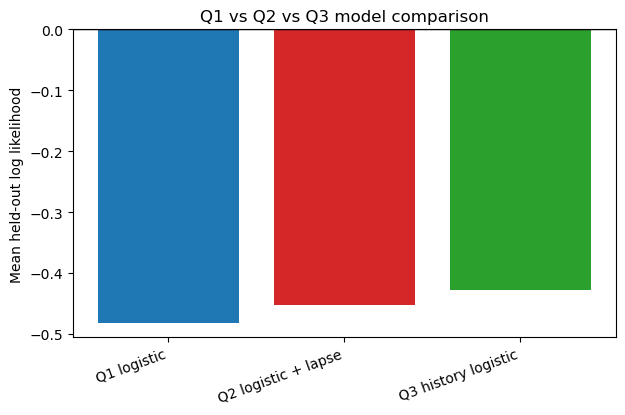

,model,mean_log_likelihood
0,Q1 logistic,-0.481672
1,Q2 logistic + lapse,-0.452052
2,Q3 history logistic,-0.427817


In [49]:
mean_model_scores_q3 = pd.DataFrame({
    'model': [
        'Q1 logistic',
        'Q2 logistic + lapse',
        'Q3 history logistic'
    ],
    'mean_log_likelihood': [
        comparison_q1_q2_q3_df['log_likelihood'].mean(),
        comparison_q1_q2_q3_df['log_likelihood_lapse'].mean(),
        comparison_q1_q2_q3_df['log_likelihood_q3'].mean()
    ]
})

plt.figure(figsize=(7, 4))
plt.bar(
    mean_model_scores_q3['model'],
    mean_model_scores_q3['mean_log_likelihood'],
    color=['tab:blue', 'tab:red', 'tab:green']
)
plt.ylabel('Mean held-out log likelihood')
plt.title('Q1 vs Q2 vs Q3 model comparison')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.show()

display(mean_model_scores_q3)


## Q3 interaction: previous choice x previous reward

If `prev_choice_weight` is mostly positive, then choices are autocorrelated: the previous choice helps predict the current choice.

If Q3 has higher log-likelihood than Q1 and Q2, then adding past choice and reward improved prediction.

If Q3 does not improve log-likelihood, then the history variables do not improve the held-out prediction for this dataset/model version.


### Q3-7. Add previous_choice x previous_reward interaction

This is a copy-based extension of Q3.

The original Q3 model tested whether previous choice and previous reward separately help predict current choice:

```text
choice ~ signed_contrast + previous_choice + previous_reward
```

Now we add an interaction:

```text
choice ~ signed_contrast + previous_choice + previous_reward + previous_choice x previous_reward
```

What this gives us:

- It tests whether the effect of previous choice depends on whether the previous trial was rewarded.

- Positive interaction means previous-choice repetition is stronger after reward, like a win-stay effect.

- Negative interaction means reward weakens previous-choice repetition, or unrewarded trials create stronger history effects.

- If the interaction improves held-out log likelihood, then this richer history model predicts behavior better than original Q3.

I use centered variables for the interaction:

```text
previous choice: 0/1 becomes -1/+1

previous reward: 0/1 becomes -1/+1
```

This makes the interaction coefficient easier to interpret.


In [50]:
# Q3 interaction copy. Do not change df_q3_model or old Q3 results.

df_q3_interaction = df_q3_model.copy(deep=True)

df_q3_interaction['prev_choice_centered'] = (
    df_q3_interaction['prev_choice_binary'].astype(float) * 2 - 1
)

df_q3_interaction['prev_reward_centered'] = (
    df_q3_interaction['prev_rewarded'].astype(float) * 2 - 1
)

df_q3_interaction['prev_choice_x_reward'] = (
    df_q3_interaction['prev_choice_centered']
    * df_q3_interaction['prev_reward_centered']
)

q3_interaction_feature_columns = [
    'signed_contrast',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward'
]

display(
    df_q3_interaction[[
        'subject',
        'session',
        'choice_binary',
        'signed_contrast',
        'prev_choice_binary',
        'prev_rewarded',
        'prev_choice_centered',
        'prev_reward_centered',
        'prev_choice_x_reward'
    ]].head()
)

print('Q3 interaction data shape:', df_q3_interaction.shape)


,subject,session,choice_binary,signed_contrast,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,0.0625,1,0,1.0,-1.0,-1.0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,-0.1250,1,1,1.0,1.0,1.0
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,-0.0000,1,0,1.0,-1.0,-1.0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,-0.0000,1,0,1.0,-1.0,-1.0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,-0.2500,0,1,-1.0,1.0,-1.0


Q3 interaction data shape: (2129698, 43)


### Q3-8. Fit logistic regression with the interaction

The key new coefficient is:

```text
prev_choice_x_reward_weight
```

Interpretation:

- positive value: previous choice has stronger effect after reward

- negative value: previous choice has weaker effect after reward

- value near zero: little evidence that reward changes the previous-choice effect


In [51]:
mouse_models_q3_interaction = {}

for subject, mouse_data in df_q3_interaction.groupby('subject'):

    X_q3_interaction = mouse_data[q3_interaction_feature_columns]
    y_q3_interaction = mouse_data['choice_binary']

    if y_q3_interaction.nunique() < 2:
        continue

    X_train_q3_interaction, X_test_q3_interaction, y_train_q3_interaction, y_test_q3_interaction = train_test_split(
        X_q3_interaction,
        y_q3_interaction,
        test_size=0.2,
        random_state=0,
        stratify=y_q3_interaction
    )

    model_q3_interaction = LogisticRegression(max_iter=1000)
    model_q3_interaction.fit(X_train_q3_interaction, y_train_q3_interaction)

    class_1_index_q3_interaction = list(model_q3_interaction.classes_).index(1)
    p_test_q3_interaction = model_q3_interaction.predict_proba(X_test_q3_interaction)[:, class_1_index_q3_interaction]

    log_likelihood_q3_interaction = -log_loss(
        y_test_q3_interaction,
        p_test_q3_interaction,
        labels=[0, 1]
    )

    mouse_models_q3_interaction[subject] = {
        'model': model_q3_interaction,
        'X_train': X_train_q3_interaction,
        'X_test': X_test_q3_interaction,
        'y_train': y_train_q3_interaction,
        'y_test': y_test_q3_interaction,
        'p_test_q3_interaction': p_test_q3_interaction,
        'log_likelihood_q3_interaction': log_likelihood_q3_interaction,
        'bias_q3_interaction': model_q3_interaction.intercept_[0],
        'contrast_weight_q3_interaction': model_q3_interaction.coef_[0][0],
        'prev_choice_weight_centered': model_q3_interaction.coef_[0][1],
        'prev_reward_weight_centered': model_q3_interaction.coef_[0][2],
        'prev_choice_x_reward_weight': model_q3_interaction.coef_[0][3]
    }

print('Number of Q3 interaction mouse models:', len(mouse_models_q3_interaction))


Number of Q3 interaction mouse models: 119


### Q3-9. Save Q3 interaction results

This creates a new table and does not overwrite `q3_results_df`.


In [52]:
q3_interaction_results = []

for subject, result in mouse_models_q3_interaction.items():
    q3_interaction_results.append({
        'subject': subject,
        'bias_q3_interaction': result['bias_q3_interaction'],
        'contrast_weight_q3_interaction': result['contrast_weight_q3_interaction'],
        'prev_choice_weight_centered': result['prev_choice_weight_centered'],
        'prev_reward_weight_centered': result['prev_reward_weight_centered'],
        'prev_choice_x_reward_weight': result['prev_choice_x_reward_weight'],
        'log_likelihood_q3_interaction': result['log_likelihood_q3_interaction']
    })

q3_interaction_results_df = pd.DataFrame(q3_interaction_results)

display(q3_interaction_results_df.head())

print('Mean interaction weight:', q3_interaction_results_df['prev_choice_x_reward_weight'].mean())
print('Median interaction weight:', q3_interaction_results_df['prev_choice_x_reward_weight'].median())
print('Mice with positive interaction:', (q3_interaction_results_df['prev_choice_x_reward_weight'] > 0).sum())
print('Mice with negative interaction:', (q3_interaction_results_df['prev_choice_x_reward_weight'] < 0).sum())


,subject,bias_q3_interaction,contrast_weight_q3_interaction,prev_choice_weight_centered,prev_reward_weight_centered,prev_choice_x_reward_weight,log_likelihood_q3_interaction
0,CSHL045,-0.063551,7.469667,0.768717,0.073065,0.267086,-0.406107
1,CSHL046,-0.154665,4.783540,0.851215,0.181728,0.154878,-0.430546
2,CSHL047,-0.835128,4.981961,0.721053,-0.291670,-0.018169,-0.410913
3,CSHL049,0.399390,6.766843,0.644235,0.008783,0.144478,-0.408931
4,CSHL051,-0.479185,3.442646,0.983881,-0.037833,0.191089,-0.429854


Mean interaction weight: 0.11929365012978282
Median interaction weight: 0.13123408685016144
Mice with positive interaction: 100
Mice with negative interaction: 19


### Q3-10. Compare original Q3 vs Q3 with interaction

If the interaction model has higher held-out log likelihood, the combined history term adds useful predictive information.


In [53]:
comparison_q1_q2_q3_interaction_df = (
    comparison_q1_q2_q3_df.copy(deep=True)
    .merge(q3_interaction_results_df, on='subject')
)

comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'] = (
    comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction']
    - comparison_q1_q2_q3_interaction_df['log_likelihood_q3']
)

comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q1'] = (
    comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction']
    - comparison_q1_q2_q3_interaction_df['log_likelihood']
)

comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q2'] = (
    comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction']
    - comparison_q1_q2_q3_interaction_df['log_likelihood_lapse']
)

q3_interaction_model_columns = [
    'log_likelihood',
    'log_likelihood_lapse',
    'log_likelihood_q3',
    'log_likelihood_q3_interaction'
]

comparison_q1_q2_q3_interaction_df['best_model_with_interaction'] = (
    comparison_q1_q2_q3_interaction_df[q3_interaction_model_columns]
    .idxmax(axis=1)
    .replace({
        'log_likelihood': 'Q1 logistic',
        'log_likelihood_lapse': 'Q2 logistic + lapse',
        'log_likelihood_q3': 'Q3 history logistic',
        'log_likelihood_q3_interaction': 'Q3 history + interaction'
    })
)

print('Mean Q3 log likelihood:', comparison_q1_q2_q3_interaction_df['log_likelihood_q3'].mean())
print('Mean Q3 interaction log likelihood:', comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction'].mean())
print('Mean improvement vs Q3:', comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'].mean())
print('Mice improved vs Q3:', (comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'] > 0).sum(), '/', len(comparison_q1_q2_q3_interaction_df))

display(
    comparison_q1_q2_q3_interaction_df[[
        'subject',
        'log_likelihood_q3',
        'log_likelihood_q3_interaction',
        'q3_interaction_improvement_vs_q3',
        'prev_choice_x_reward_weight',
        'best_model_with_interaction'
    ]].head()
)


Mean Q3 log likelihood: -0.4278173880978828
Mean Q3 interaction log likelihood: -0.42674689234925417
Mean improvement vs Q3: 0.001070495748628581
Mice improved vs Q3: 89 / 119


,subject,log_likelihood_q3,log_likelihood_q3_interaction,q3_interaction_improvement_vs_q3,prev_choice_x_reward_weight,best_model_with_interaction
0,CSHL045,-0.408899,-0.406107,0.002792,0.267086,Q3 history + interaction
1,CSHL046,-0.434661,-0.430546,0.004115,0.154878,Q3 history + interaction
2,CSHL047,-0.410820,-0.410913,-0.000093,-0.018169,Q2 logistic + lapse
3,CSHL049,-0.409152,-0.408931,0.000221,0.144478,Q3 history + interaction
4,CSHL051,-0.431315,-0.429854,0.001461,0.191089,Q3 history + interaction


### Q3-10b. Bar plot including Q3 interaction

This is the same model-comparison plot as Q3-6, but now it also includes the interaction model.

Important: this cell must run after `comparison_q1_q2_q3_interaction_df` is created.


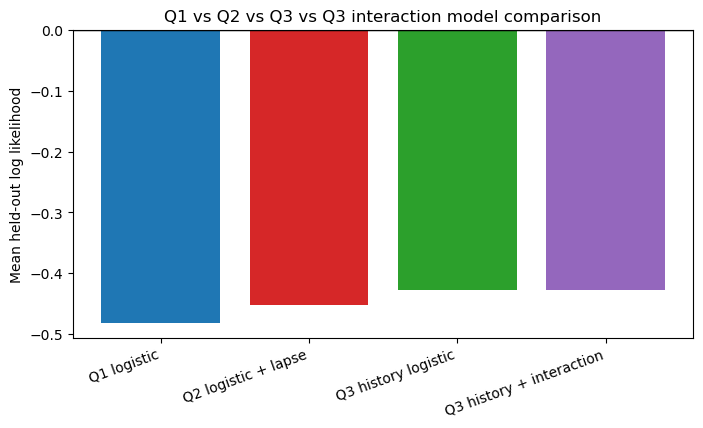

,model,mean_log_likelihood
0,Q1 logistic,-0.481672
1,Q2 logistic + lapse,-0.452052
2,Q3 history logistic,-0.427817
3,Q3 history + interaction,-0.426747


In [54]:
mean_model_scores_q3_interaction = pd.DataFrame({
    'model': [
        'Q1 logistic',
        'Q2 logistic + lapse',
        'Q3 history logistic',
        'Q3 history + interaction'
    ],
    'mean_log_likelihood': [
        comparison_q1_q2_q3_interaction_df['log_likelihood'].mean(),
        comparison_q1_q2_q3_interaction_df['log_likelihood_lapse'].mean(),
        comparison_q1_q2_q3_interaction_df['log_likelihood_q3'].mean(),
        comparison_q1_q2_q3_interaction_df['log_likelihood_q3_interaction'].mean()
    ]
})

plt.figure(figsize=(8, 4))
plt.bar(
    mean_model_scores_q3_interaction['model'],
    mean_model_scores_q3_interaction['mean_log_likelihood'],
    color=['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
)
plt.ylabel('Mean held-out log likelihood')
plt.title('Q1 vs Q2 vs Q3 vs Q3 interaction model comparison')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.show()

display(mean_model_scores_q3_interaction)


### Q3-11. Visualize the interaction result

Left: distribution of interaction weights across mice.

Right: improvement of Q3 interaction model over original Q3.


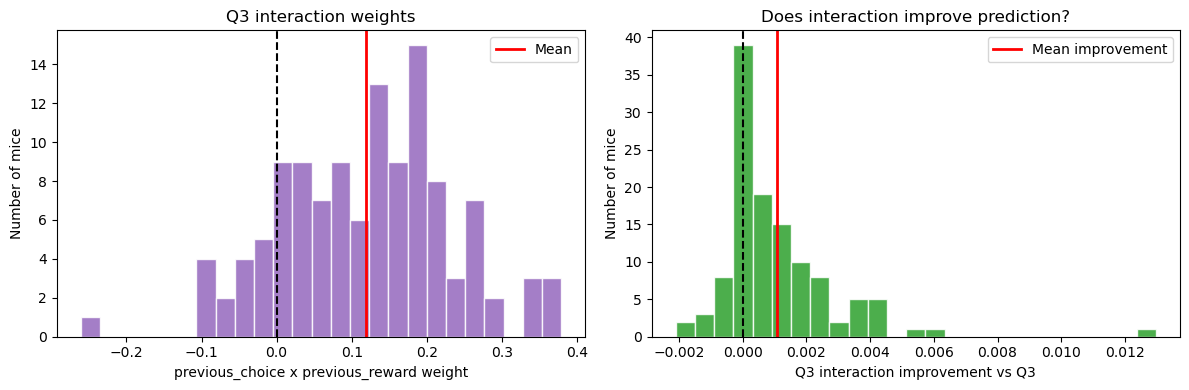

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    q3_interaction_results_df['prev_choice_x_reward_weight'],
    bins=25,
    color='tab:purple',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].axvline(
    q3_interaction_results_df['prev_choice_x_reward_weight'].mean(),
    color='red',
    linewidth=2,
    label='Mean'
)
axes[0].set_xlabel('previous_choice x previous_reward weight')
axes[0].set_ylabel('Number of mice')
axes[0].set_title('Q3 interaction weights')
axes[0].legend()

axes[1].hist(
    comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'],
    bins=25,
    color='tab:green',
    edgecolor='white',
    alpha=0.85
)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].axvline(
    comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'].mean(),
    color='red',
    linewidth=2,
    label='Mean improvement'
)
axes[1].set_xlabel('Q3 interaction improvement vs Q3')
axes[1].set_ylabel('Number of mice')
axes[1].set_title('Does interaction improve prediction?')
axes[1].legend()

plt.tight_layout()
plt.show()


### Q3-12. Final interaction interpretation

This prints the short answer: what the interaction gives us.


In [56]:
mean_interaction_weight = q3_interaction_results_df['prev_choice_x_reward_weight'].mean()
mean_interaction_improvement = comparison_q1_q2_q3_interaction_df['q3_interaction_improvement_vs_q3'].mean()
n_positive_interaction = (q3_interaction_results_df['prev_choice_x_reward_weight'] > 0).sum()
n_total_interaction = len(q3_interaction_results_df)

print('Q3 interaction final answer')
print('---------------------------')
print('Mean previous_choice x previous_reward weight:', mean_interaction_weight)
print('Mean improvement over original Q3:', mean_interaction_improvement)
print('Mice with positive interaction:', n_positive_interaction, '/', n_total_interaction)
print()

if mean_interaction_weight > 0:
    print('Interpretation: previous choice has a stronger effect after rewarded trials.')
    print('This supports a win-stay-like history effect.')
elif mean_interaction_weight < 0:
    print('Interpretation: previous choice has a weaker effect after rewarded trials, or stronger effect after unrewarded trials.')
    print('This suggests history dependence is not simple win-stay behavior.')
else:
    print('Interpretation: the interaction is close to zero on average.')
    print('Previous choice and previous reward mostly act independently in this model.')

if mean_interaction_improvement > 0:
    print('Prediction: adding the interaction improves held-out log likelihood compared with original Q3.')
else:
    print('Prediction: adding the interaction does not improve held-out log likelihood compared with original Q3 on average.')

print()
print('What this term gives us:')
print('Original Q3 asks whether previous choice and previous reward matter separately.')
print('The interaction asks whether reward changes the effect of previous choice.')
print('So it tests a richer history strategy, especially win-stay / lose-shift-like behavior.')


Q3 interaction final answer
---------------------------
Mean previous_choice x previous_reward weight: 0.11929365012978282
Mean improvement over original Q3: 0.001070495748628581
Mice with positive interaction: 100 / 119

Interpretation: previous choice has a stronger effect after rewarded trials.
This supports a win-stay-like history effect.
Prediction: adding the interaction improves held-out log likelihood compared with original Q3.

What this term gives us:
Original Q3 asks whether previous choice and previous reward matter separately.
The interaction asks whether reward changes the effect of previous choice.
So it tests a richer history strategy, especially win-stay / lose-shift-like behavior.


# Q3 MY NOTES

**Lose-shift** значит:  

  если мышь **не получила reward**, она на следующем trial **меняет сторону**.

- Для этого нужны 3 колонки:

  - `prev_choice_binary` = что выбрала мышь на прошлом trial

  - `prev_rewarded` = получила ли reward на прошлом trial

  - `choice_binary` = что выбрала сейчас

- Мы проверяем:
  - прошлый trial был **not rewarded**

  - текущий choice **не такой**, как previous choice

- Если оба условия true:

```text
lose-shift-like behavior
```

- Пример:

| previous choice | previous reward | current choice | meaning |
|---|---|---|---|
| left | no reward | right | lose-shift |
| right | no reward | left | lose-shift |
| left | reward | left | win-stay |
| right | reward | right | win-stay |




```text
Lose-shift-like behavior means that after an unrewarded trial, the mouse switches to the opposite choice on the next trial.
```

# Q4. Is mouse behavior stationary?

`Stationary` means the mouse uses the same strategy through the whole session.

`Non-stationary` means the mouse changes strategy during the session.

In the updated Q3 model, the behavioral-history model is not only:

```text
choice ~ signed_contrast + previous_choice + previous_reward
```

Now Q3 also includes the interaction:

```text
previous_choice x previous_reward
```

So in Q4, the stationarity question becomes:

```text
Do the updated Q3 interaction-model parameters stay stable within one session?
```

Q4 tests whether these parameters change over sliding windows:

- bias
- signed contrast weight
- previous choice weight
- previous reward weight
- previous_choice x previous_reward interaction weight

If these coefficients change across windows, then behavior is non-stationary.


### Q4-1. Create a copy of updated Q3 interaction data

I do not change `df_q3_interaction` or old Q3 results.

For Q4, I make a new copy called `df_q4`.

Because Q3 changed, Q4 now uses the updated Q3 interaction model variables:

- `signed_contrast`
- `prev_choice_centered`
- `prev_reward_centered`
- `prev_choice_x_reward`
- `choice_binary`

This means Q4 tests whether the **interaction model parameters** are stationary within the session.


In [57]:
# Create Q4 copy. Do not change Q3 interaction data.
df_q4 = df_q3_interaction.copy(deep=True)

# Safety check: create centered history columns if they are missing.
if 'prev_choice_centered' not in df_q4.columns:
    df_q4['prev_choice_centered'] = df_q4['prev_choice_binary'].astype(float) * 2 - 1

if 'prev_reward_centered' not in df_q4.columns:
    df_q4['prev_reward_centered'] = df_q4['prev_rewarded'].astype(float) * 2 - 1

if 'prev_choice_x_reward' not in df_q4.columns:
    df_q4['prev_choice_x_reward'] = (
        df_q4['prev_choice_centered']
        * df_q4['prev_reward_centered']
    )

q4_feature_columns = [
    'signed_contrast',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward'
]

# Sort trials in time order inside session.
sort_columns_q4 = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q4.columns
]
df_q4 = df_q4.sort_values(sort_columns_q4).copy(deep=True)

display(
    df_q4[[
        'subject',
        'session',
        'signed_contrast',
        'choice_binary',
        'prev_choice_binary',
        'prev_rewarded',
        'prev_choice_centered',
        'prev_reward_centered',
        'prev_choice_x_reward'
    ]].head()
)

print('Q4 rows:', len(df_q4))
print('Q4 stationarity features:', q4_feature_columns)


,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0,1.0,-1.0,-1.0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1,1.0,1.0,1.0
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0,1.0,-1.0,-1.0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0,1.0,-1.0,-1.0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1,-1.0,1.0,-1.0


Q4 rows: 2129698
Q4 stationarity features: ['signed_contrast', 'prev_choice_centered', 'prev_reward_centered', 'prev_choice_x_reward']


### Q4-2. We need one session for sliding-window analysis.

Requirements:

1. enough trials  
2. both choices: `0` and `1`    #q4_session_summary
3. largest valid session #at least 200 trials

- choose 1 session with enough trials

- Instead of 1 model for the whole session, we cut it into sliding windows like 150-200 trials each, shifting by 50 trials at a time.

- Refit the updated Q3 interaction model in each window:

```text
choice ~ signed_contrast
       + previous_choice
       + previous_reward
       + previous_choice x previous_reward
```

- Track how the coefficients change from window to window.

- Compare the parameters across time with a Cochran-style heterogeneity test.

If the parameters change a lot within the session, then behavior may be **non-stationary**.


write why scipy not skilearn linear regression?

In [58]:
import statsmodels.api as sm
from scipy import stats

In [59]:
# ШАГ 1. Lets settings sliding-window
# WINDOW_SIZE = how many trials go into one window.
# STEP = how far the window moves each time.
# PARAM_NAMES = model parameters we will track over time.
WINDOW_SIZE = 200
STEP = 50
PARAM_NAMES = ['bias'] + q4_feature_columns

print('Q4 parameters tested for stationarity:')
print(PARAM_NAMES)


Q4 parameters tested for stationarity:
['bias', 'signed_contrast', 'prev_choice_centered', 'prev_reward_centered', 'prev_choice_x_reward']


In [65]:
# Шаг 2. This function fits the updated Q3 interaction logistic model inside 1 window.
# It returns coefficients and standard errors, because we need standard errors for the stationarity test.

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def fit_window_logistic(df_window):

    X = sm.add_constant(df_window[q4_feature_columns].values)
    y = df_window['choice_binary'].values

    if len(np.unique(y)) < 2:
        return None

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            result = sm.Logit(y, X).fit(
                disp=0,
                maxiter=200
            )

        return result.params, result.bse

    except Exception:
        return None


# 3. Choose example mice and sessions.
# We take 2 best mice from the updated Q3 interaction model and choose the longest session for each.
# Long sessions are needed because sliding windows need enough trials.
if 'q3_interaction_results_df' in globals():
    example_mice = (
        q3_interaction_results_df
        .sort_values('log_likelihood_q3_interaction', ascending=False)['subject']
        .head(2)
    )
else:
    example_mice = (
        q3_results_df.sort_values('log_likelihood_q3', ascending=False)['subject'].head(2)
    )

example_sessions = {
    subject: df_q4.loc[df_q4['subject'] == subject, 'session'].value_counts().idxmax()
    for subject in example_mice
}

print('Example mice:', list(example_mice))
print('Example sessions:', example_sessions)


Example mice: ['ZM_1085', 'CSH_ZAD_007']
Example sessions: {'ZM_1085': '8c985920-2434-483f-a99e-d143e7921b32', 'CSH_ZAD_007': 'b48f015d-fe02-4298-9e62-3ea9780737f6'}


WINDOW_SIZE = 200
STEP = 50

window 1: trials 0-199

window 2: trials 50-249

window 3: trials 100-299

In [66]:
# 4. Fit Q3 model in sliding windows.
# Each window gives 1 set of parameters. If parameters change across windows, behavior may be non-stationary.
window_results = {}

for subject, session in example_sessions.items(): #For each selected mouse/session, split the session into sliding windows.

    df_sess = (
        df_q4[(df_q4['subject'] == subject) & (df_q4['session'] == session)]
        .sort_values('intervals_0')
        .reset_index(drop=True)
    )

    rows = []

    for start in range(0, len(df_sess) - WINDOW_SIZE + 1, STEP): #Move a sliding window through the session.

        window = df_sess.iloc[start:start + WINDOW_SIZE] #Take the trials inside the current window.
       
        fit = fit_window_logistic(window)   #Fit Q3 logistic regression on this window.

        if fit is None:
            continue

        params, se = fit
        row = {'window_center': start + WINDOW_SIZE // 2} #We save window_center because it tells us where this window is located in the session.

        for name, p, s in zip(PARAM_NAMES, params, se): #Match each parameter name with its estimate and standard error.
            row[f'{name}_est'] = p
            row[f'{name}_se'] = s

        rows.append(row)

    window_results[(subject, session)] = pd.DataFrame(rows)


/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [67]:
# Combine all window result tables into one table
window_results_table = []

for (subject, session), df_win in window_results.items():
    df_temp = df_win.copy()
    df_temp['subject'] = subject
    df_temp['session'] = session
    window_results_table.append(df_temp)

window_results_table = pd.concat(window_results_table, ignore_index=True)

display(window_results_table.head())

,window_center,bias_est,bias_se,signed_contrast_est,signed_contrast_se,prev_choice_centered_est,prev_choice_centered_se,prev_reward_centered_est,prev_reward_centered_se,prev_choice_x_reward_est,prev_choice_x_reward_se,subject,session
0,100,0.663679,0.979617,40.680859,8.702796,-0.528598,0.975669,-0.585847,0.977905,0.764452,0.978349,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
1,150,-0.116657,2.179543,29.824366,5.568236,0.987407,2.183931,0.318227,2.180237,-0.447751,2.181890,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
2,200,-0.950579,2.210837,28.597420,5.391189,0.289341,2.203596,1.234345,2.215880,0.331679,2.204221,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
3,250,0.143893,0.473203,22.426515,3.939009,-0.586877,0.492418,-0.052634,0.471750,0.845074,0.485463,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
4,300,0.352152,0.436072,20.395480,3.469667,-0.409229,0.446804,0.035066,0.434100,0.752292,0.451756,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32


Example output from the sliding-window table:

```text
window_center   bias_est   signed_contrast_est   prev_choice_centered_est   prev_choice_x_reward_est
100             -0.2       4.5                   0.3                        0.1
150             -0.1       4.2                   0.5                        0.2
200              0.0       3.8                   0.8                        0.4
```

This code moves a 200-trial window across the session.
In each window, it fits the updated Q3 interaction logistic regression.
Then it saves the parameters from each window so we can check if they change over time.


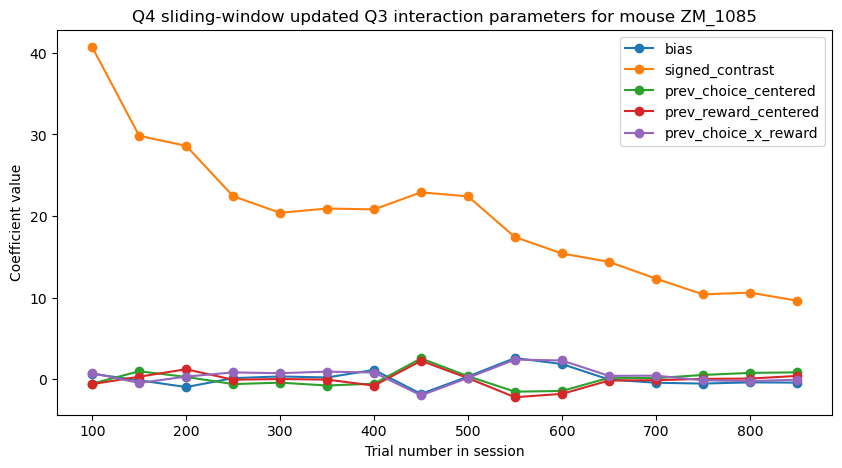

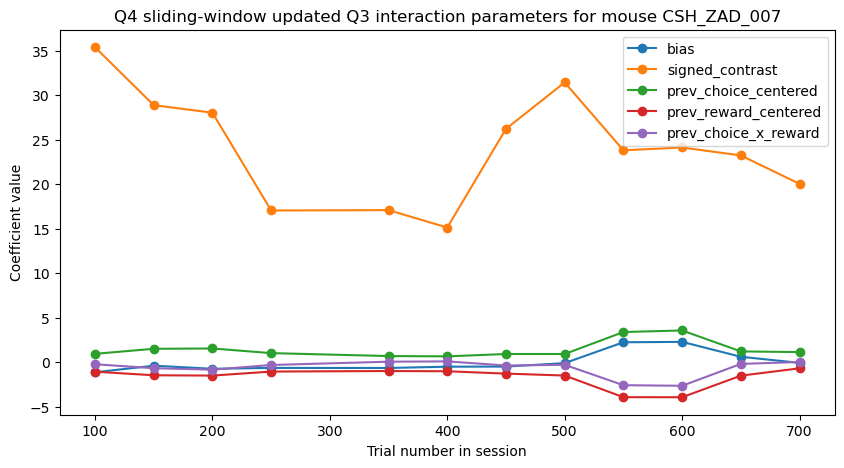

In [68]:
for subject in window_results_table['subject'].unique():

    mouse_table = window_results_table[
        window_results_table['subject'] == subject
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        mouse_table['window_center'],
        mouse_table['bias_est'],
        marker='o',
        label='bias'
    )

    for feature_name in q4_feature_columns:
        est_column = f'{feature_name}_est'
        if est_column in mouse_table.columns:
            plt.plot(
                mouse_table['window_center'],
                mouse_table[est_column],
                marker='o',
                label=feature_name
            )

    plt.xlabel('Trial number in session')
    plt.ylabel('Coefficient value')
    plt.title(f'Q4 sliding-window updated Q3 interaction parameters for mouse {subject}')
    plt.legend()
    plt.show()


Cochran-style heterogeneity statistic Q делает одну конкретную вещь:

- собирает различия между коэффициентами из всех окон в одно число и проверяет, слишком ли эти различия большие, чтобы объяснить их обычной статистической ошибкой.

- Пусть в каждом окне получен коэффициент: βi и его стандартная ошибка = SEi 

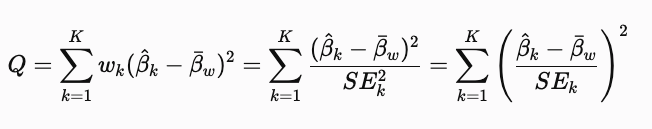

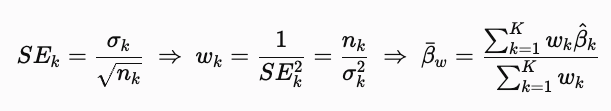

In [69]:
# 5. Test whether coefficients change across windows.
# This is a Cochran-style weighted test.
# p_value < 0.05 means the parameter changed significantly over time.
stationarity_results = []

for (subject, session), df_win in window_results.items():
    
    for name in PARAM_NAMES:          #contrast, previous_choice, previous_reward.
        est = df_win[f'{name}_est'].values #get оценки выбранного коэффициента из всех окон.
        se = df_win[f'{name}_se'].values     #берёт standard error этого коэффициента для каждого окна.

        weights = 1 / se**2     #calculate the weights. Чем меньше ошибка, тем больше доверие к оценке. 
        mean_est = np.sum(weights * est) / np.sum(weights)  #считает общий взвешенный средний коэффициент

        Q = np.sum(weights * (est - mean_est) ** 2)    #измеряет, насколько коэффициенты разных окон отличаются от общего среднего
        dof = len(est) - 1           #число степеней свободы K — количество окон.
        p = stats.chi2.sf(Q, dof)    #вычисляет вероятность получить такой большой Q, если коэффициент на самом деле не менялся. p value

        stationarity_results.append({
            'subject': subject,
            'parameter': name,
            'p_value': p,
            'significant_change': p < 0.05
        })


# 6. Final stationarity result table.
# If significant_change is True, that parameter is not stable across the session.
stationarity_table = pd.DataFrame(stationarity_results)
display(stationarity_table)

,subject,parameter,p_value,significant_change
0,ZM_1085,bias,7.698215e-01,False
1,ZM_1085,signed_contrast,1.604951e-07,True
2,ZM_1085,prev_choice_centered,2.286794e-01,False
3,ZM_1085,prev_reward_centered,9.967557e-01,False
4,ZM_1085,prev_choice_x_reward,7.895519e-01,False
5,CSH_ZAD_007,bias,8.578119e-01,False
6,CSH_ZAD_007,signed_contrast,3.373068e-02,True
7,CSH_ZAD_007,prev_choice_centered,9.986855e-01,False
8,CSH_ZAD_007,prev_reward_centered,9.965102e-01,False
9,CSH_ZAD_007,prev_choice_x_reward,9.983773e-01,False


### Null hypothesis

$$
H_0:\ \beta_1=\beta_2=\cdots=\beta_K
$$

**The coefficient is the same across all windows.**
**Коэффициент одинаковый во всех окнах.**

| p-value       | Interpretation                                                                                                                                                         |
| ------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| $p < 0.05$    | **Reject $H_0$:** the coefficient changed over time. <br> **Отклоняем $H_0$:** коэффициент менялся со временем.                                                        |
| $p \geq 0.05$ | **Fail to reject $H_0$:** there is not enough evidence that the coefficient changed. <br> **Не отклоняем $H_0$:** недостаточно доказательств, что коэффициент менялся. |
